## Group Members:
- Nurul Ika Syafiny Binti Azhar (A23CS0164)
- Lubna Al Haani Binti Radzuan (A23CS0107)
- Nuraisyah Binti Mohd Zikre (A23CS0160)

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [59]:
import pandas as pd

# 1. Data loaded
# Load and clean dataset
df = pd.read_csv("Rainfall.csv", header=None)
df = df[0].str.split(",", expand=True)
df.columns = ["Region", "Year", "Month", "Station", "Rainfall_mm", "RainyDays", "MaxTemp_C", "MinTemp_C", "UrbanRural"]
df = df.drop(index=0).reset_index(drop=True)
# Convert numeric columns
numeric_cols = ["Year", "Rainfall_mm", "RainyDays", "MaxTemp_C", "MinTemp_C"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 2. Display first 5 rows
print("First 5 rows:")
display(df.head())

# 3. Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 4. Summary statistics
print("\nSummary statistics:")
print(df.describe())

First 5 rows:


,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
0,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
1,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
2,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
3,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
4,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban



Missing values per column:
Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64

Summary statistics:
         Year  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
count    10.0    10.000000   10.00000  10.000000  10.000000
mean   2023.0    66.160000   10.90000  16.100000   4.740000
std       0.0    12.154121    1.66333   2.982542   2.029888
min    2023.0    45.700000    8.00000  11.200000   1.800000
25%    2023.0    59.825000   10.00000  14.775000   3.050000
50%    2023.0    62.450000   11.00000  16.100000   5.100000
75%    2023.0    76.075000   12.00000  18.125000   6.050000
max    2023.0    84.200000   13.00000  20.100000   7.700000


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [61]:
# Groupby station then aggregte the value using .agg functions
station = df.groupby('Station').agg({
    'Rainfall_mm':'sum',
    'RainyDays':'mean',
    'MaxTemp_C':'mean',
    'MinTemp_C':'mean'
})

# Rename columns
station = station.rename(columns={
    'Rainfall_mm': 'Total Rainfall (mm)',
    'RainyDays': 'Average Rainy Days',
    'MaxTemp_C': 'Average MaxTemp (C)',
    'MinTemp_C': 'Average MinTemp (C)'
})

display(station)

,Total Rainfall (mm),Average Rainy Days,Average MaxTemp (C),Average MinTemp (C)
Station,,,,
StationA,128.3,10.5,13.40,2.75
StationB,122.0,10.5,13.10,2.50
StationC,144.4,12.0,19.85,7.45
StationD,105.3,9.0,16.65,5.90
StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [63]:
# Groupby Region and UrbanRural then aggregte the value using .agg functions
region_urban = df.groupby(['Region', 'UrbanRural']).agg({
    'Rainfall_mm':'mean',
    'MaxTemp_C':'mean',
    'RainyDays':'mean'
})

# Rename columns
region_urban = region_urban.rename(columns={
    'Rainfall_mm': 'Average Rainfall (mm)',
    'MaxTemp_C': 'Average MaxTemp (C)',
    'RainyDays': 'Average Rainy Days'
})

display(region_urban)

Average Rainfall (mm)  Average MaxTemp (C)  \
Region UrbanRural                                               
East   Rural                       52.65                16.65   
North  Rural                       61.00                13.10   
       Urban                       64.15                13.40   
South  Urban                       72.20                19.85   
West   Urban                       80.80                17.50   

                   Average Rainy Days  
Region UrbanRural                      
East   Rural                      9.0  
North  Rural                     10.5  
       Urban                     10.5  
South  Urban                     12.0  
West   Urban                     12.5

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall



In [65]:
# Create list of function with column name
func = [('Total Rainfall (mm)','sum'),
        ('Average Rainfall (mm)','mean'),
        ('Minimum Rainfall (mm)','min'),
        ('Maximum Rainfall (mm)','max')
       ]

# Groupby Month and Region then aggregte the value using .agg functions
month_region = df.groupby(['Month', 'Region']).agg({'Rainfall_mm': func})

display(month_region)

Rainfall_mm                                              \
             Total Rainfall (mm) Average Rainfall (mm) Minimum Rainfall (mm)   
Month Region                                                                   
Feb   East                  59.6                 59.60                  59.6   
      North                 72.1                 72.10                  72.1   
      South                 63.4                 63.40                  63.4   
      West                  84.2                 84.20                  84.2   
Jan   East                  45.7                 45.70                  45.7   
      North                116.7                 58.35                  56.2   
      South                 81.0                 81.00                  81.0   
      West                  77.4                 77.40                  77.4   
Mar   North                 61.5                 61.50                  61.5   

                                    
             Maximum Rainfall (mm)  
Month Region                        
Feb   East                    59.6  
      North                   72.1  
      South                   63.4  
      West                    84.2  
Jan   East                    45.7  
      North                   60.5  
      South                   81.0  
      West                    77.4  
Mar   North                   61.5

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [67]:
# Find the row with the maximum Rainfall_mm
max_rf = df.loc[df['Rainfall_mm'].idxmax()]

# Extract Region, Month, and Rainfall
region = max_rf['Region']
month = max_rf['Month']
rf = max_rf['Rainfall_mm']

print(f"The {region} recorded highest rainfall: {rf} mm in {month}")

The West recorded highest rainfall: 84.2 mm in Feb


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [69]:
# Create list of function with column name
func2 = [('Average Rainfall (mm)','mean'),
        ('Minimum Rainfall (mm)','min'),
        ('Maximum Rainfall (mm)','max')
       ]

# Groupby Year and UrbanRural then aggregte the value using .agg functions
year_urban = df.groupby(['Year', 'UrbanRural']).agg({'Rainfall_mm': func2})

display(year_urban)

Rainfall_mm                        \
                Average Rainfall (mm) Minimum Rainfall (mm)   
Year UrbanRural                                               
2023 Rural                  56.825000                  45.7   
     Urban                  72.383333                  56.2   

                                       
                Maximum Rainfall (mm)  
Year UrbanRural                        
2023 Rural                       61.5  
     Urban                       84.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [71]:
# Calculate temperature range each row
df['TempRange'] = df['MaxTemp_C'] - df['MinTemp_C']

# Group by Region and Month, then take the mean of TempRange
avg_temp_range = df.groupby(['Region', 'Month']).agg(
    Average_Temp_Range_C =('TempRange', 'mean')
)

display(avg_temp_range)

Average_Temp_Range_C
Region Month                      
East   Feb                    11.7
       Jan                     9.8
North  Feb                    11.7
       Jan                     9.5
       Mar                    11.8
South  Feb                    12.4
       Jan                    12.4
West   Feb                    12.9
       Jan                    11.9

## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



(array([0, 1, 2, 3]),
 [Text(0, 0, 'East'),
  Text(1, 0, 'North'),
  Text(2, 0, 'South'),
  Text(3, 0, 'West')])

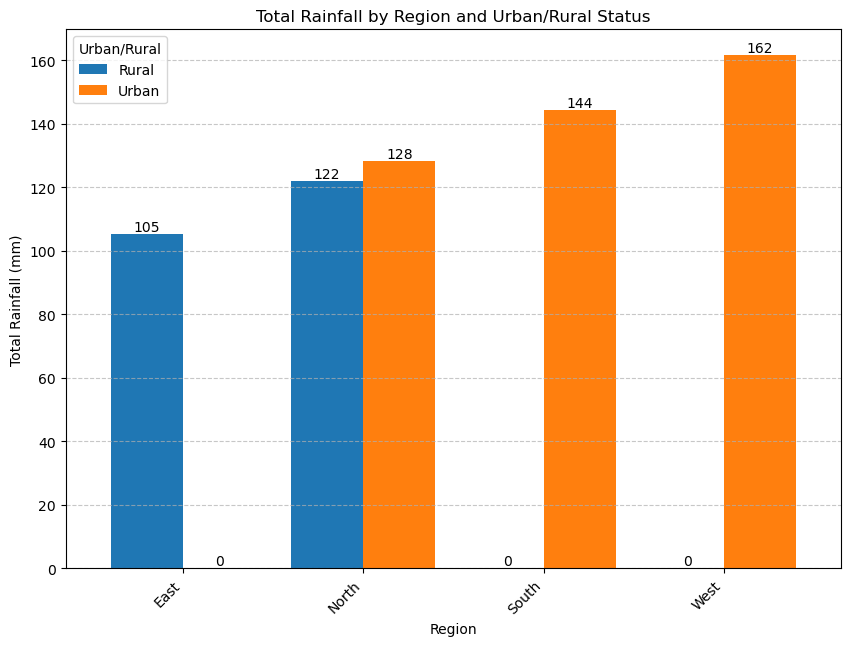

In [198]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

total_rainfall_by_region_urban = df.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 7))
total_rainfall_by_region_urban.plot(kind='bar', ax=ax, width=0.8)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge')

ax.set_title('Total Rainfall by Region and Urban/Rural Status')
ax.set_xlabel('Region')
ax.set_ylabel('Total Rainfall (mm)')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Urban/Rural')
plt.xticks(rotation=45, ha='right')

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



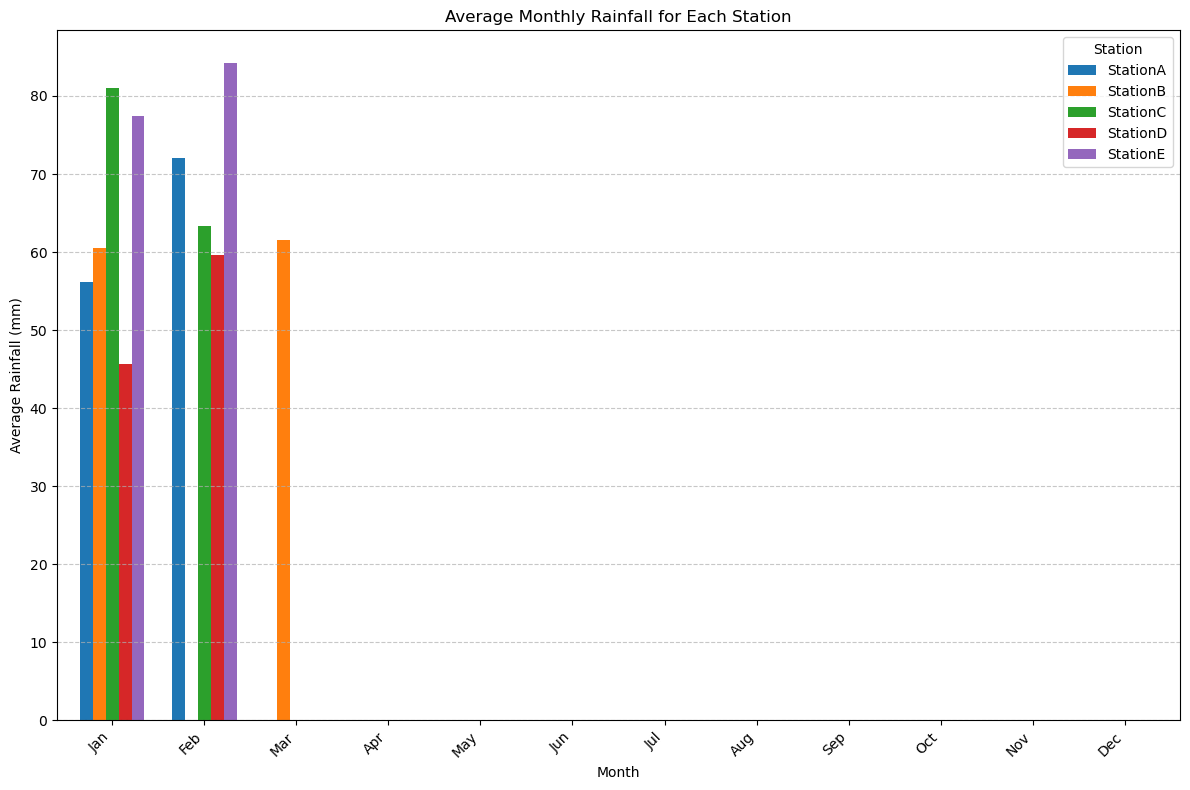

In [194]:
#Write your code here
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Calculate average monthly rainfall for each station
avg_monthly_rainfall_station = (df.groupby(['Month', 'Station'], observed=False)['Rainfall_mm'].mean().unstack())

fig, ax = plt.subplots(figsize=(12, 8))
avg_monthly_rainfall_station.plot(kind='bar', ax=ax, width=0.7)

ax.set_title('Average Monthly Rainfall for Each Station')
ax.set_xlabel('Month')
ax.set_ylabel('Average Rainfall (mm)')
ax.legend(title='Station')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Jan'),
  Text(1, 0, 'Feb'),
  Text(2, 0, 'Mar'),
  Text(3, 0, 'Apr'),
  Text(4, 0, 'May'),
  Text(5, 0, 'Jun'),
  Text(6, 0, 'Jul'),
  Text(7, 0, 'Aug'),
  Text(8, 0, 'Sep'),
  Text(9, 0, 'Oct'),
  Text(10, 0, 'Nov'),
  Text(11, 0, 'Dec')])

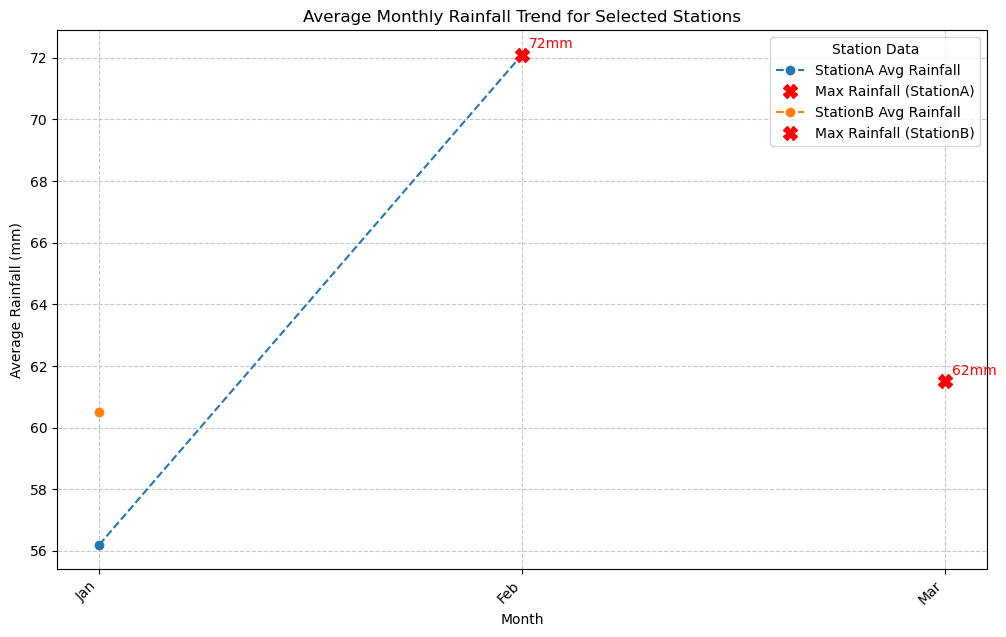

In [210]:
#Write your code here
#Select first two unique station
selected_stations = df['Station'].unique()[:2] # Taking the first two unique stations

# Aggregate data for selected stations
rainfall_trend_selected_stations = (df[df['Station'].isin(selected_stations)].groupby(['Month', 'Station'], observed=False)['Rainfall_mm'].mean().unstack().reindex(month_order))

fig, ax = plt.subplots(figsize=(12, 7))

for station in selected_stations:
    # Plot the line for the station
    ax.plot(rainfall_trend_selected_stations.index, rainfall_trend_selected_stations[station],
            marker='o', linestyle='--', label=f'{station} Avg Rainfall')

    # Highlight month with maximum rainfall for this station
    max_rainfall_month = rainfall_trend_selected_stations[station].idxmax()
    max_rainfall_value = rainfall_trend_selected_stations[station].max()
    ax.plot(max_rainfall_month, max_rainfall_value, 'X', color='red', markersize=10, label=f'Max Rainfall ({station})')
    ax.annotate(f'{max_rainfall_value:.0f}mm',
                xy=(max_rainfall_month, max_rainfall_value),
                xytext=(5, 5), textcoords='offset points', color='red', fontsize=10)


ax.set_title('Average Monthly Rainfall Trend for Selected Stations')
ax.set_xlabel('Month')
ax.set_ylabel('Average Rainfall (mm)')
ax.legend(title='Station Data')
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



(0.0, 92.62)

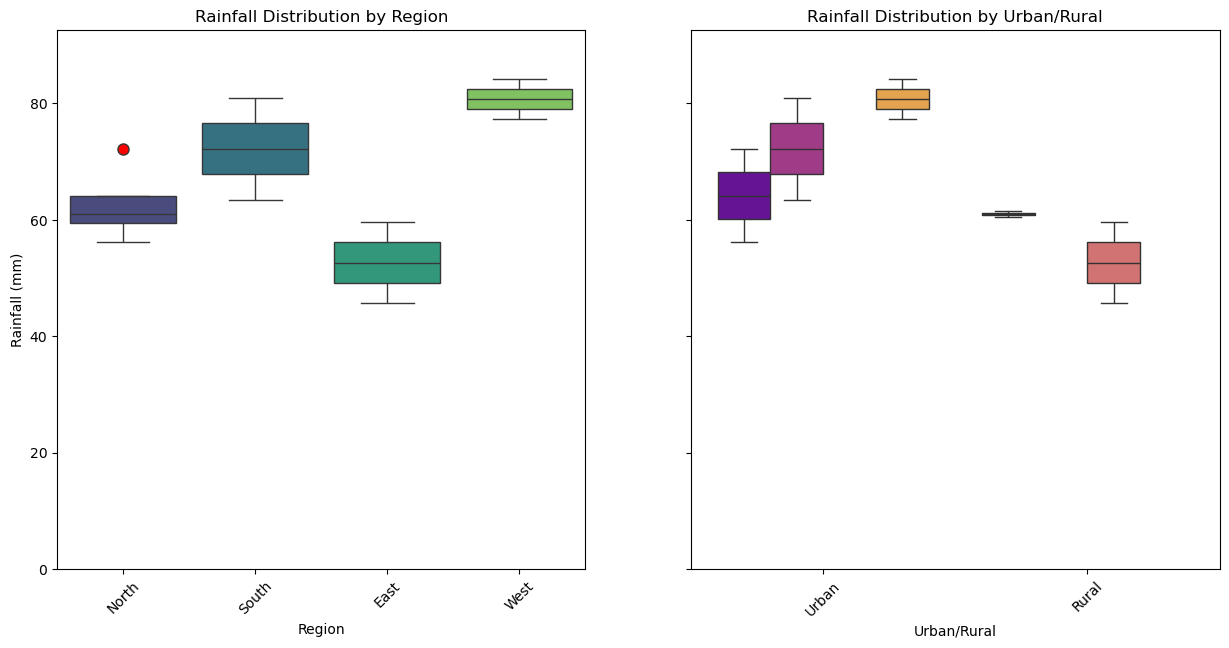

In [216]:
#Write your code here
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# Boxplot by Region
sns.boxplot(x='Region', y='Rainfall_mm',  hue='Region', data=df, ax=axes[0], palette='viridis', legend=False,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none'))
axes[0].set_title('Rainfall Distribution by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, df['Rainfall_mm'].max() * 1.1) # Set y-axis limit

# Boxplot by Urban/Rural
sns.boxplot(x='UrbanRural', y='Rainfall_mm',  hue='Region', data=df, ax=axes[1], palette='plasma', legend=False,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none'))
axes[1].set_title('Rainfall Distribution by Urban/Rural')
axes[1].set_xlabel('Urban/Rural')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, df['Rainfall_mm'].max() * 1.1)

5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



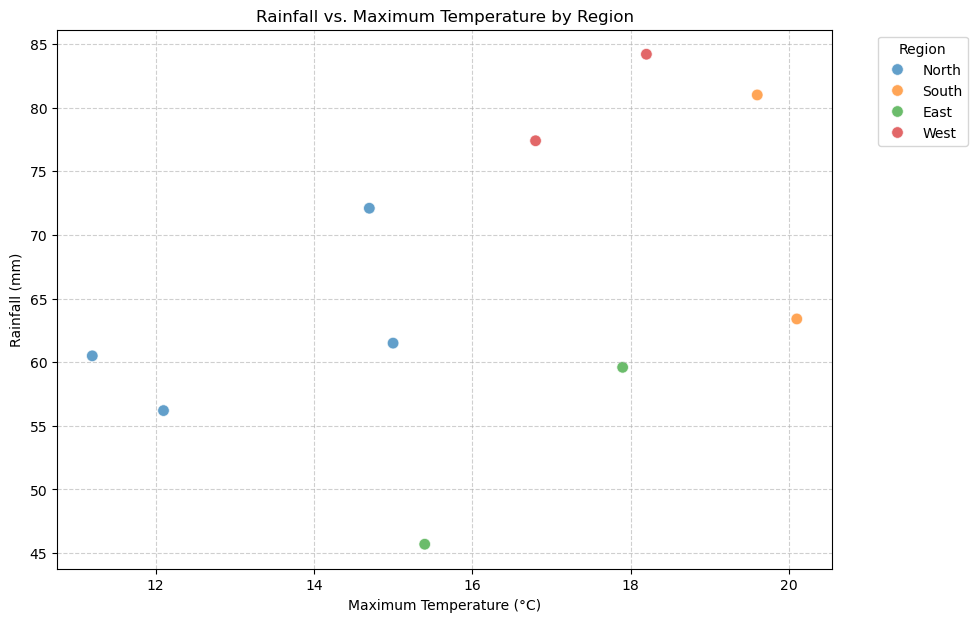

In [218]:
#Write your code here
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(x='MaxTemp_C', y='Rainfall_mm', hue='Region', data=df, ax=ax, s=70, alpha=0.7)

ax.set_title('Rainfall vs. Maximum Temperature by Region')
ax.set_xlabel('Maximum Temperature (°C)')
ax.set_ylabel('Rainfall (mm)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



Text(120.72222222222221, 0.5, 'Region')

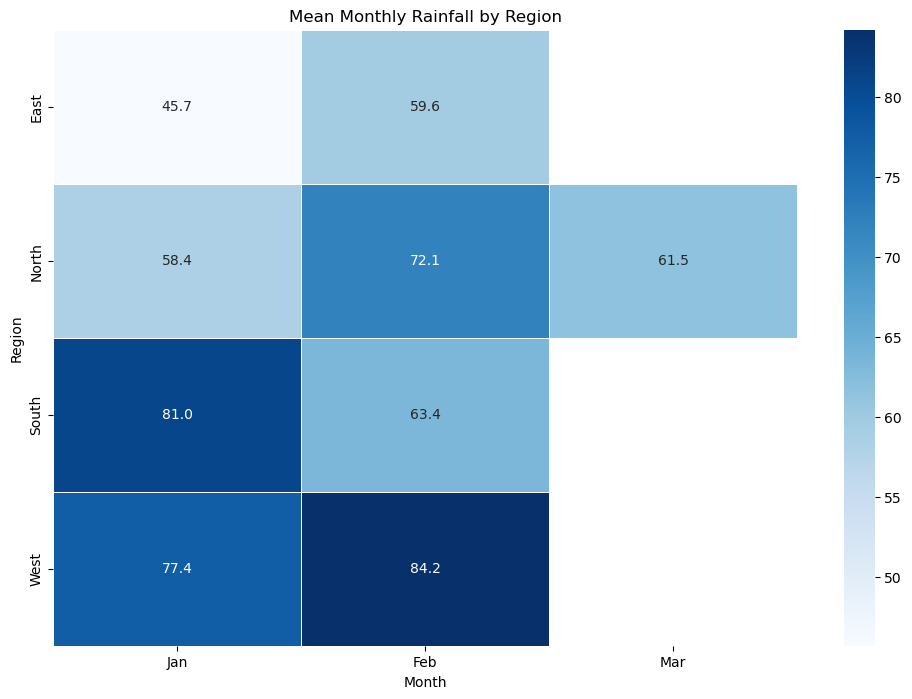

In [220]:
#Write your code here
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Pivot table for heatmap
mean_monthly_rainfall_pivot = df.pivot_table(values='Rainfall_mm', index='Region', columns='Month', aggfunc='mean',  observed=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(mean_monthly_rainfall_pivot, annot=True, fmt=".1f", cmap="Blues", linewidths=.5, ax=ax)

ax.set_title('Mean Monthly Rainfall by Region')
ax.set_xlabel('Month')
ax.set_ylabel('Region')

7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [224]:
#Write your code here
#Barplot 
plt.tight_layout()
plt.savefig('total_rainfall_by_region_urban_bar_chart.png')
plt.show()

#Grouped Bar Chart
plt.tight_layout()
plt.savefig('avg_monthly_rainfall_station_grouped_bar_chart.png')
plt.show()

#Line plot
plt.tight_layout()
plt.savefig('rainfall_trend_line_plot.png')
plt.show()

#Boxplot
plt.tight_layout()
plt.savefig('rainfall_distribution_boxplots.png')
plt.show()

#Scatter plot
plt.tight_layout()
plt.savefig('rainfall_vs_maxtemp_scatter_plot.png')
plt.show()

#Heatmap
plt.tight_layout()
plt.savefig('mean_monthly_rainfall_heatmap.png')
plt.show()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


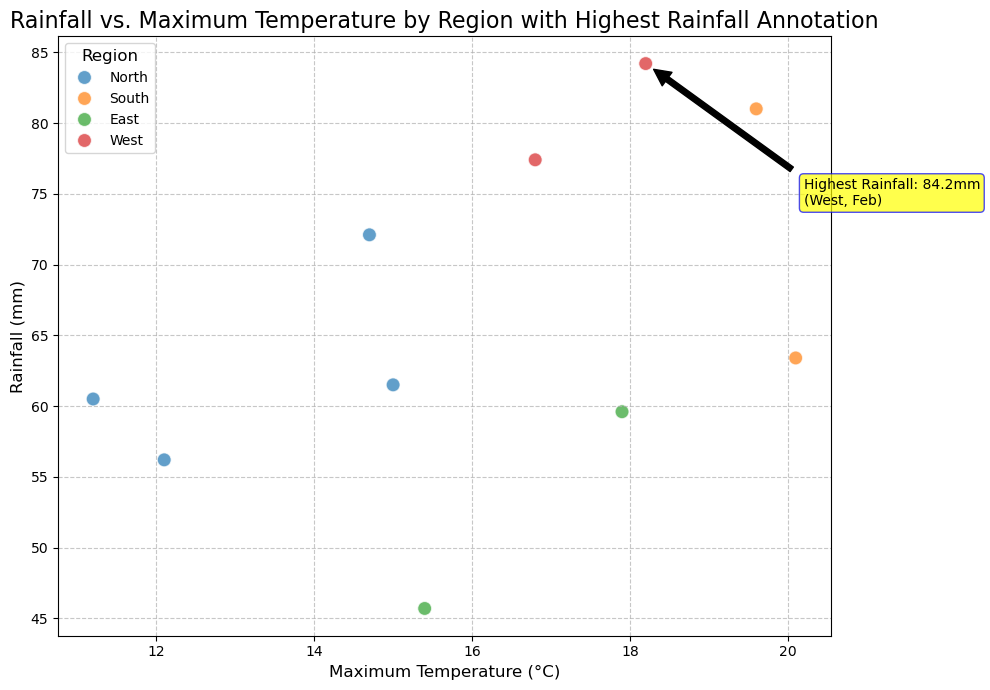

In [87]:
#Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Using the scatter plot for annotation
plt.figure(figsize=(10, 7))
sns.scatterplot(x='MaxTemp_C', y='Rainfall_mm', hue='Region', data=df, s=100, alpha=0.7)

# Find the point with the highest rainfall
max_rainfall_point = df.loc[df['Rainfall_mm'].idxmax()]
plt.annotate(
    f"Highest Rainfall: {max_rainfall_point['Rainfall_mm']:.1f}mm\n({max_rainfall_point['Region']}, {max_rainfall_point['Month']})",
    xy=(max_rainfall_point['MaxTemp_C'], max_rainfall_point['Rainfall_mm']),
    xytext=(max_rainfall_point['MaxTemp_C'] + 2, max_rainfall_point['Rainfall_mm'] - 10),
    arrowprops=dict(facecolor='black', shrink=0.05),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.7)
)

plt.title('Rainfall vs. Maximum Temperature by Region with Highest Rainfall Annotation', fontsize=16)
plt.xlabel('Maximum Temperature (°C)', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Region', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.savefig('rainfall_vs_maxtemp_scatter_plot_annotated.png')
plt.show()


2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


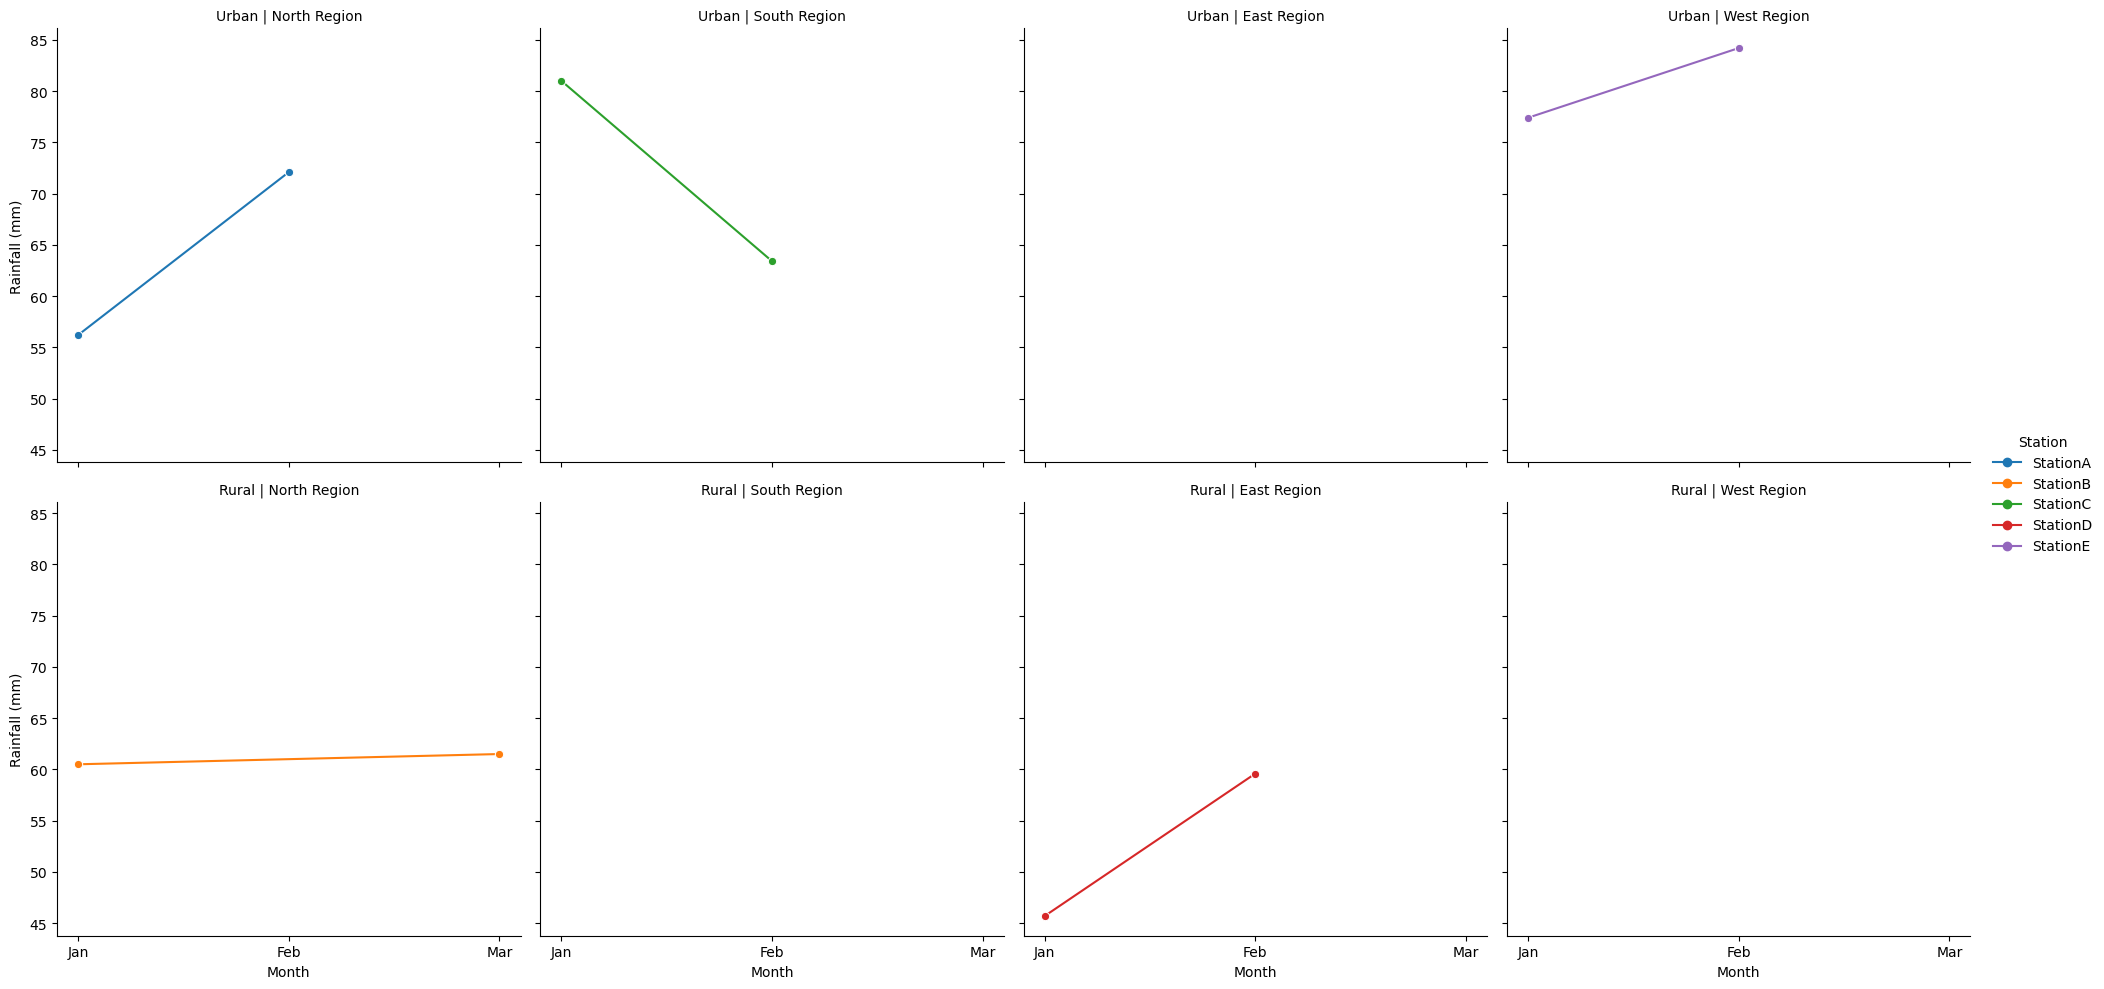

In [89]:
# make Month categorical for correct order
df['Month'] = pd.Categorical(df['Month'], categories=['Jan', 'Feb', 'Mar'], ordered=True)

# Create the facet grid plot
g = sns.relplot(
    data=df,
    x='Month',
    y='Rainfall_mm',
    kind='line',
    col='Region',
    row='UrbanRural',
    hue='Station',  # Optional: color by Station if multiple stations
    marker='o',
    errorbar=None
)

g.set_axis_labels("Month", "Rainfall (mm)")
g.set_titles(row_template='{row_name}', col_template='{col_name} Region')

plt.show()

3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here
# Based on the data exploration, grouping and aggregation, and data visualizations, here are some key insights:

* **Regional Rainfall Patterns:** There is clear differences in total and average rainfall across regions. Some regions consistently receive more rainfall than others, as seen in the total rainfall bar chart and the mean monthly rainfall heatmap. This suggests that it is due to  varying climatic conditions or geographical influences.

* **Urban vs. Rural Rainfall:** The analysis showed how rainfall differs between urban and rural areas within regions. The grouped bar chart and boxplots illustrate these distinctions, which potentially highlighting the impact of urbanization on local weather patterns or differences in weather station placement.

* **Monthly Variability:** Rainfall patterns exhibit significant monthly variability. The line plots clearly show the seasonal trends, with certain months experiencing peak rainfall, which is consistent across regions but with differing magnitudes. The heatmap further reinforces these seasonal variations across all regions.

* **Temperature Influence:** The scatter plot between rainfall and maximum temperature generally indicates that higher temperatures do not necessarily correlate with higher rainfall, and the relationship varies by region. Some regions might show a slight positive correlation, while others might not, or even show a slight negative one, indicating complex meteorological factors at play beyond simple temperature.

* **Temperature Range:** The average temperature range calculation per region provides insight into the diurnal or monthly temperature fluctuations. Regions with higher temperature ranges might experience more extreme weather events, or have clearer seasonal transitions.

* **Missing Data Handling:** The initial data exploration revealed the presence of missing values, which were handled by imputation (mean for numerical, mode for categorical). This ensures the integrity of subsequent analyses and visualizations.